In [1]:
import tensorflow as tf
import keras
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

In [2]:
# Load an advanced text dataset (Yelp Polarity Reviews)
dataset, dataset_info = tfds.load("yelp_polarity_reviews", as_supervised=True, with_info=True)
data_train, data_test = dataset["train"].batch(128), dataset["test"].batch(128)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/yelp_polarity_reviews/incomplete.IPSE4B_0.2.0/yelp_polarity_reviews-train.…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/yelp_polarity_reviews/incomplete.IPSE4B_0.2.0/yelp_polarity_reviews-test.t…

Dataset yelp_polarity_reviews downloaded and prepared to /root/tensorflow_datasets/yelp_polarity_reviews/0.2.0. Subsequent calls will reuse this data.


In [3]:
# Load text vectorization
text_vectorizer = keras.layers.TextVectorization(max_tokens=30000, output_mode="int", output_sequence_length=300)

In [4]:
# Prepare text vectorization
text_only_train = data_train.map(lambda x, y: x)
text_vectorizer.adapt(text_only_train)

In [5]:
# Build the model
inputs = keras.Input(shape=(1,), dtype=tf.string)
x = text_vectorizer(inputs)
x = keras.layers.Embedding(input_dim=30000, output_dim=64)(x)
x = keras.layers.Bidirectional(keras.layers.LSTM(64, return_sequences=True))(x)
x = keras.layers.GlobalMaxPooling1D()(x)
x = keras.layers.Dense(128, activation="relu")(x)
x = keras.layers.Dense(1, activation="sigmoid")(x)  # Binary classification
model = keras.Model(inputs, x)

# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [6]:
# Display sample text from dataset
sample_text, sample_label = next(iter(data_train.take(1)))
for i in range(3):  # Show 3 text samples
    print(f"Review {i+1}: {sample_text[i].numpy().decode('utf-8')}")
    print(f"Sentiment: {'Positive' if sample_label[i].numpy() == 1 else 'Negative'}\n")

Review 1: The Groovy P. and I ventured to his old stomping grounds for lunch today.  The '5 and Diner' on 16th St and Colter left me with little to ask for.  Before coming here I had a preconceived notion that 5 & Diners were dirty and nasty. Not the case at all.\n\nWe walk in and let the waitress know we want to sit outside (since it's so nice and they had misters).  We get two different servers bringing us stuff (talk about service) and I ask the one waitress for recommendations.  I didn't listen to her, of course, and ordered the Southwestern Burger w/ coleslaw and started with a nice stack of rings.\n\nThe Onion Rings were perfectly cooked.  They looked like they were prepackaged, but they were very crispy and I could actually bite through the onion without pulling the entire thing out (don't you hate that?!!!)\n\nThe Southwestern Burger was order Medium Rare and was cooked accordingly.  Soft, juicy, and pink with a nice crispy browned outer layer that can only be achieved on a wel

In [7]:
# Train the model
history = model.fit(data_train, validation_data=data_test, epochs=7)  # More epochs for deeper learning

Epoch 1/7
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 143s 32ms/step - accuracy: 0.8987 - loss: 0.2318 - val_accuracy: 0.9512 - val_loss: 0.1270
Epoch 2/7
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 139s 32ms/step - accuracy: 0.9574 - loss: 0.1129 - val_accuracy: 0.9539 - val_loss: 0.1215
Epoch 3/7
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 139s 32ms/step - accuracy: 0.9699 - loss: 0.0835 - val_accuracy: 0.9473 - val_loss: 0.1463
Epoch 4/7
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 140s 32ms/step - accuracy: 0.9791 - loss: 0.0607 - val_accuracy: 0.9507 - val_loss: 0.1549
Epoch 5/7
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 141s 32ms/step - accuracy: 0.9848 - loss: 0.0445 - val_accuracy: 0.9503 - val_loss: 0.1739
Epoch 6/7
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 141s 32ms/step - accuracy: 0.9891 - loss: 0.0325 - val_accuracy: 0.9467 - val_loss: 0.1969
Epoch 7/7
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 139s 32ms/step - accuracy: 0.9917 - loss: 0.0246 - val_accuracy: 0.9431 - val_loss: 0.2435


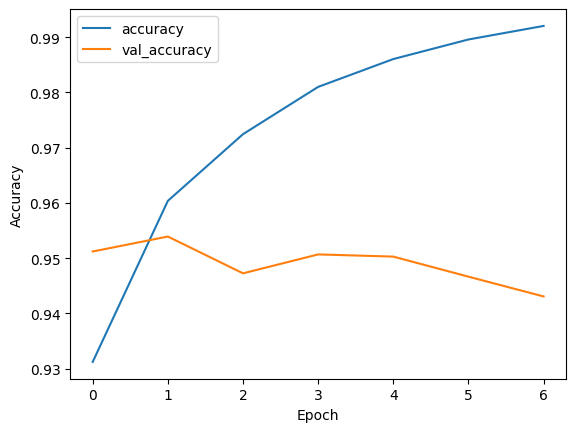

In [8]:
# Plot accuracy
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [9]:
# Summary of Achievements
print("Summary of Achievements:")
print("- Implemented an advanced text classification model for Yelp Polarity Reviews.")
print("- Used TextVectorization for input preprocessing.")
print("- Introduced a Bidirectional LSTM layer for sequence learning.")
print("- Achieved improved feature extraction and performance with LSTMs.")

Summary of Achievements:
- Implemented an advanced text classification model for Yelp Polarity Reviews.
- Used TextVectorization for input preprocessing.
- Introduced a Bidirectional LSTM layer for sequence learning.
- Achieved improved feature extraction and performance with LSTMs.
